# Analysis

This files combines the steps of our analysis. Since any analysis of the LIS dataset has to be performed in a secured environment the following code is not reproducible on its own. To ensure transparency we provide the input code and the respective outputs below.

## DiD Models

In [ ]:
library(lissyrtools)
library(tidyverse)
library(fixest)

variables <- c("hours1", "iso2", "year", "sex", "pwgt", "marital", "age", "educ", "nchildren", "lfs")
countries <- c("lu", "be", "fr", "de", "es", "ie") # Removed Poland because of missing hour variable

lis_datasets <- lissyuse(data = countries, vars  = variables, from = 2012, to = 2023)

names(lis_datasets)

lis_all <- lis_datasets |>
  imap(\(df, nm) df |>
         select(any_of(variables)) |>
         mutate(iso2 = substr(nm, 1, 2),
                year = 2000L + as.integer(substr(nm, 3, 4)))) |>
  bind_rows() |>
  transmute(country = iso2, year,
            female  = as.integer(sex) - 1L,
            hours   = case_when(
                        lfs %in% c(200, 300, 340) & is.na(hours1) ~ 0,
                        TRUE ~ as.numeric(hours1)),
            weight  = as.numeric(pwgt),
            married = as.integer(marital) %in% c(100, 110),
            never_married = as.integer(marital) == 210,
            agew    = age >= 20 & age <= 55,
            treat   = as.integer(iso2 == "lu" & year >= 2018),
            # Controls
            edu    = as.factor(educ),
            child  = case_when(
                        nchildren > 0 ~ 1,
                        nchildren == 0 ~ 0))

# Diagnostics

#table(lis_all$treat, useNA = "ifany")
#table(lis_all$country, lis_all$year)
#class(lis_all$marital); attr(lis_all$marital, "labels")
#table(lis_all$married, useNA = "ifany")
#table(lis_all$female, useNA = "ifany")

# Preparing subset for estimating the models

lis_est <- lis_all |> filter(female == 1, married, agew)

# Model 1 (w/o controls)

m1 <- feols (hours ~ treat | country + year, data = lis_est, weights = ~weight, cluster = ~country)

# Model 2 (w/ controls)

m2 <- feols (hours ~ treat + edu + child | country + year, data = lis_est, weights = ~weight, cluster = ~country)

# Robustness checks

# Model 3: Treatment group = married men

lis_est_men <- lis_all |> filter(female == 0, married, agew)

m3 <- feols (hours ~ treat | country + year, data = lis_est_men, weights = ~weight, cluster = ~country)

# Model 4: Treatment group = unmarried women

lis_est_unmarried <- lis_all |> filter(female == 1, never_married, agew)

m4 <- feols (hours ~ treat | country + year, data = lis_est_unmarried, weights = ~weight, cluster = ~country)

# Model output

models <- list("Baseline" = m1, "Baseline with controls" = m2, "Placebo (married men)" = m3, "Placebo (never married women)" = m4)

etable(models, se.below = TRUE, digits = 3,
       fitstat = ~ n + r2 + wr2
       #drop = "age"
       )

res <- rbind(
  broom::tidy(m1) |> transform(model = 1),
  broom::tidy(m2) |> transform(model = 2),
  broom::tidy(m3) |> transform(model = 3),
  broom::tidy(m4) |> transform(model = 4)
)
gof <- data.frame(
  model = 1:4,
  nobs  = sapply(list(m1,m2,m3,m4), nobs),
  r2    = sapply(list(m1,m2,m3,m4), function(x) fixest::r2(x, "r2"))
)
write.csv(res, row.names = FALSE)
cat("---GOF---\n")
write.csv(gof, row.names = FALSE)


### Output:

In [ ]:

> options(
+   echo = FALSE, 
+   encoding = "UTF-8"
+ )
Loading required package: readstata13
> 
> options(error = expression(q('no')))
> library(lissyrtools)
Loading required package: haven
Warning message:
package ‘lissyrtools’ was built under R version 4.5.2 
> library(tidyverse)
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
> library(fixest)
> variables <- c("hours1", "iso2", "year", "sex", "pwgt", "marital", "age", "educ", "nchildren", "lfs")
> countries <- c("lu", "be", "fr", "de", "es", "ie") # Removed Poland because of missing hour variable
> lis_datasets <- lissyuse(data = countries, vars  = variables, from = 2012, to = 2023)
The list contains the following `person-level` data frames: be23p, be22p, be21p, be20p, be19p, be18p, be17p, be16p, be15p, be14p, be13p, be12p, fr22p, fr21p, fr20p, fr19p, fr18p, fr17p, fr16p, fr15p, fr14p, fr13p, fr12p, de22p, de21p, de20p, de19p, de18p, de17p, de16p, de15p, de14p, de13p, de12p, ie23p, ie22p, ie21p, ie20p, ie19p, ie18p, ie17p, ie16p, ie15p, ie14p, ie13p, ie12p, lu23p, lu22p, lu21p, lu20p, lu19p, lu18p, lu17p, lu16p, lu15p, lu14p, lu13p, lu12p, es22p, es21p, es20p, es19p, es18p, es17p, es16p, es15p, es14p, es13p, es12p.
 
> names(lis_datasets)
 [1] "be23p" "be22p" "be21p" "be20p" "be19p" "be18p" "be17p" "be16p" "be15p"
[10] "be14p" "be13p" "be12p" "fr22p" "fr21p" "fr20p" "fr19p" "fr18p" "fr17p"
[19] "fr16p" "fr15p" "fr14p" "fr13p" "fr12p" "de22p" "de21p" "de20p" "de19p"
[28] "de18p" "de17p" "de16p" "de15p" "de14p" "de13p" "de12p" "ie23p" "ie22p"
[37] "ie21p" "ie20p" "ie19p" "ie18p" "ie17p" "ie16p" "ie15p" "ie14p" "ie13p"
[46] "ie12p" "lu23p" "lu22p" "lu21p" "lu20p" "lu19p" "lu18p" "lu17p" "lu16p"
[55] "lu15p" "lu14p" "lu13p" "lu12p" "es22p" "es21p" "es20p" "es19p" "es18p"
[64] "es17p" "es16p" "es15p" "es14p" "es13p" "es12p"
> lis_all <- lis_datasets |>
+   imap(\(df, nm) df |>
+          select(any_of(variables)) |>
+          mutate(iso2 = substr(nm, 1, 2),
+                 year = 2000L + as.integer(substr(nm, 3, 4)))) |>
+   bind_rows() |>
+   transmute(country = iso2, year,
+             female  = as.integer(sex) - 1L,
+             hours   = case_when(
+                         lfs %in% c(200, 300, 340) & is.na(hours1) ~ 0,
+                         TRUE ~ as.numeric(hours1)),
+             weight  = as.numeric(pwgt),
+             married = as.integer(marital) %in% c(100, 110),
+             never_married = as.integer(marital) == 210,
+             agew    = age >= 20 & age <= 55,
+             treat   = as.integer(iso2 == "lu" & year >= 2018),
+             # Controls
+             edu    = as.factor(educ),
+             child  = case_when(
+                         nchildren > 0 ~ 1,
+                         nchildren == 0 ~ 0))
> # Diagnostics
> #table(lis_all$treat, useNA = "ifany")
> #table(lis_all$country, lis_all$year)
> #class(lis_all$marital); attr(lis_all$marital, "labels")
> #table(lis_all$married, useNA = "ifany")
> #table(lis_all$female, useNA = "ifany")
> # Preparing subset for estimating the models
> lis_est <- lis_all |> filter(female == 1, married, agew)
> # Model 1 (w/o controls)
> m1 <- feols (hours ~ treat | country + year, data = lis_est, weights = ~weight, cluster = ~country)
NOTES: 8,959 observation removed because of 0-weight.
       21,761 observations removed because of NA values (LHS: 21,761).
> # Model 2 (w/ controls)
> m2 <- feols (hours ~ treat + edu + child | country + year, data = lis_est, weights = ~weight, cluster = ~country)
NOTES: 8,959 observation removed because of 0-weight.
       24,584 observations removed because of NA values (LHS: 21,761, RHS: 11,618).
> # Robustness checks
> # Model 3: Treatment group = married men
> lis_est_men <- lis_all |> filter(female == 0, married, agew)
> m3 <- feols (hours ~ treat | country + year, data = lis_est_men, weights = ~weight, cluster = ~country)
NOTES: 8,924 observation removed because of 0-weight.
       19,703 observations removed because of NA values (LHS: 19,703).
> # Model 4: Treatment group = unmarried women
> lis_est_unmarried <- lis_all |> filter(female == 1, never_married, agew)
> m4 <- feols (hours ~ treat | country + year, data = lis_est_unmarried, weights = ~weight, cluster = ~country)
NOTE: 39,741 observations removed because of NA values (LHS: 39,741).
> # Model output
> models <- list("Baseline" = m1, "Baseline with controls" = m2, "Placebo (married men)" = m3, "Placebo (never married women)" = m4)
> etable(models, se.below = TRUE, digits = 3,
+        fitstat = ~ n + r2 + wr2
+        #drop = "age"
+        )
                Baseline Baseli.. Placeb.. Placeb...1
Dependent Var.:    hours    hours    hours      hours
                                                     
treat             1.34    -0.184   -2.19        0.264
                 (0.584)  (0.589)  (0.887)     (1.08)
edu2                       6.46*                     
                          (1.62)                     
edu3                      12.4**                     
                          (1.86)                     
child                     -4.86*                     
                          (1.48)                     
Fixed-Effects:  -------- -------- --------   --------
country              Yes      Yes      Yes        Yes
year                 Yes      Yes      Yes        Yes
_______________ ________ ________ ________   ________
S.E.: Clustered by: co.. by: co.. by: co..   by: co..
Observations     257,721  255,440  229,122    168,547
R2               0.01741  0.09905  0.01434    0.04094
Within R2        0.00023  0.08290  0.00093    7.94e-6
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
> res <- rbind(
+   broom::tidy(m1) |> transform(model = 1),
+   broom::tidy(m2) |> transform(model = 2),
+   broom::tidy(m3) |> transform(model = 3),
+   broom::tidy(m4) |> transform(model = 4)
+ )
> gof <- data.frame(
+   model = 1:4,
+   nobs  = sapply(list(m1,m2,m3,m4), nobs),
+   r2    = sapply(list(m1,m2,m3,m4), function(x) fixest::r2(x, "r2"))
+ )
> write.csv(res, row.names = FALSE)
"term","estimate","std.error","statistic","p.value","model"
"treat",1.33650266784738,0.584373856800317,2.28706786296922,0.0709087084637422,1
"treat",-0.18416979946731,0.588684422502999,-0.312849792566698,0.767022973112176,2
"edu2",6.45735930987478,1.61582938955073,3.99631257584081,0.0103612819358421,2
"edu3",12.4122398388743,1.86129957598923,6.66858790438263,0.00114500005651949,2
"child",-4.86366752295649,1.47811774713624,-3.29044660506887,0.0217028259042618,2
"treat",-2.19297060063543,0.887264917257536,-2.47160747368861,0.056418823675711,3
"treat",0.263663263855864,1.07802687946578,0.244579489508205,0.816502072497377,4
> cat("---GOF---\n")
---GOF---
> write.csv(gof, row.names = FALSE)
"model","nobs","r2"
1,257721,0.0174132737567483
2,255440,0.0990484906996785
3,229122,0.0143437782365005
4,168547,0.0409360987382864
> 
> proc.time()
   user  system elapsed 
 13.592   0.981  21.143


## Trend plot

In [ ]:
library(lissyrtools)
library(tidyverse)

variables <- c("hours1", "iso2", "year", "sex", "pwgt", "marital", "age")
countries <- c("lu", "be", "fr", "de", "es", "ie", "pl")
country_names <- c(
  lu = "Luxembourg",
  be = "Belgium",
  fr = "France",
  de = "Germany",
  es = "Spain",
  ie = "Ireland"
)

lis_datasets <- lissyuse(data = countries, vars  = variables, from = 2012, to = 2023)

names(lis_datasets)

lis_all <- lis_datasets |>
  imap(\(df, nm) df |>
         select(any_of(variables)) |>
         mutate(iso2 = substr(nm, 1, 2),
                year = 2000L + as.integer(substr(nm, 3, 4)))) |>
  bind_rows() |>
  transmute(country = iso2, year,
            female  = as.integer(sex) - 1L,
            hours   = as.numeric(hours1),
            weight  = as.numeric(pwgt),
            married = as.integer(marital) %in% c(100, 110),
            agew    = age >= 20 & age <= 55,
            treat   = as.integer(iso2 == "lu" & year >= 2018)) |>
  mutate(country = factor(country,
                          levels = names(country_names),
                          labels = unname(country_names)))

# Plot 1

p1_data <- lis_all |>
  filter(!is.na(hours), hours >= 0, !is.na(weight),
         female == 1, agew, married) |>
  group_by(country, year) |>
  summarise(mean_hours = weighted.mean(hours, w = weight, na.rm = TRUE),
            n_cell     = n(),
            .groups    = "drop")

p1 <- ggplot(p1_data, aes(x = year, y = mean_hours, color = country)) +
  geom_line(linewidth = 0.5) +
  geom_point(size = 1) +
  geom_vline(xintercept = 2018, linetype = "dashed", linewidth = 0.3) +
  scale_x_continuous(breaks = 2012:2023, limits = c(2012, 2023)) +
  labs(
      # title = "Hours Worked (Main Job) of partnered women aged 20–55",
       x = "Year", y = "Mean weekly hours (weighted)", color = "Country") +
  theme_minimal()

print(png(file = paste0(USR_PDF, "/p1.png"),
          width = 2000, height = 1500, res = 300))
print(p1)
dev.off()


### Output:

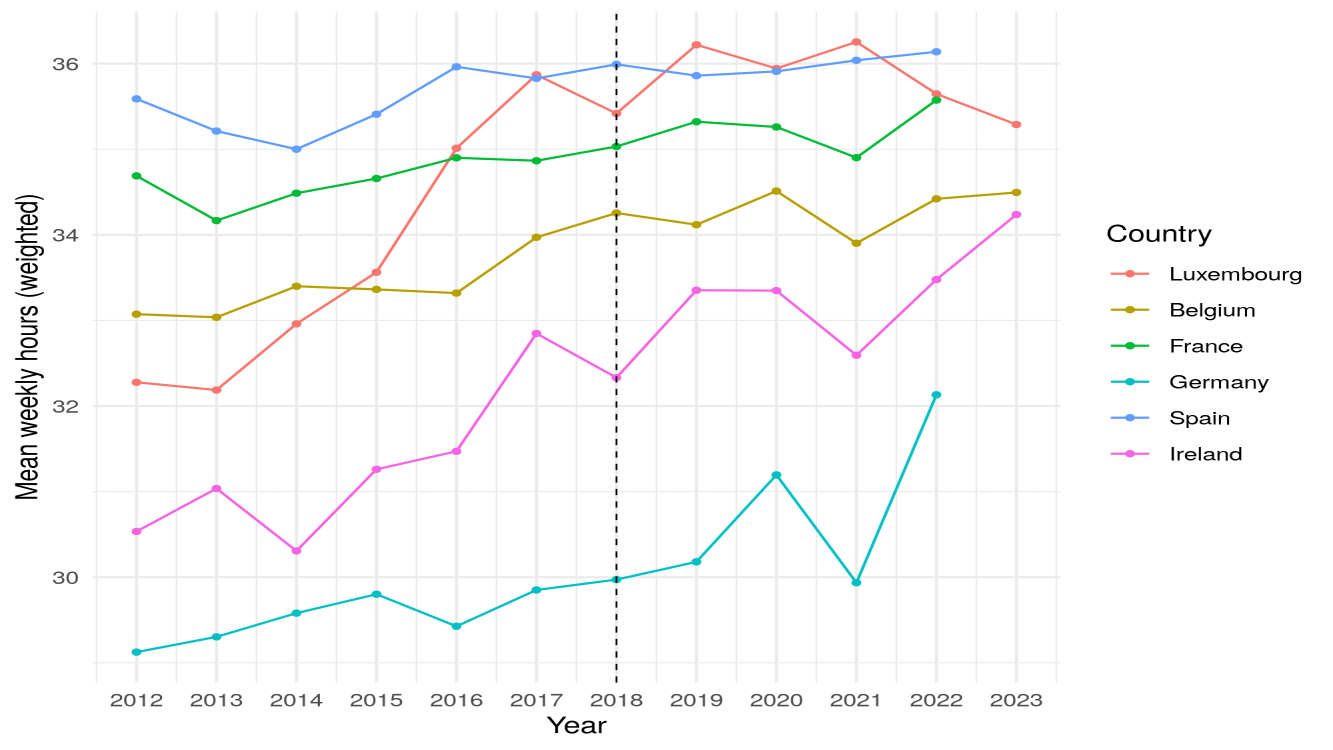

In [ ]:

> options(
+   echo = FALSE, 
+   encoding = "UTF-8"
+ )
Loading required package: readstata13
> 
> options(error = expression(q('no')))
> library(lissyrtools)
Loading required package: haven
Warning message:
package ‘lissyrtools’ was built under R version 4.5.2 
> library(tidyverse)
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
> variables <- c("hours1", "iso2", "year", "sex", "pwgt", "marital", "age")
> countries <- c("lu", "be", "fr", "de", "es", "ie", "pl")
> country_names <- c(
+   lu = "Luxembourg",
+   be = "Belgium",
+   fr = "France",
+   de = "Germany",
+   es = "Spain",
+   ie = "Ireland"
+ )
> lis_datasets <- lissyuse(data = countries, vars  = variables, from = 2012, to = 2023)
The list contains the following `person-level` data frames: be23p, be22p, be21p, be20p, be19p, be18p, be17p, be16p, be15p, be14p, be13p, be12p, fr22p, fr21p, fr20p, fr19p, fr18p, fr17p, fr16p, fr15p, fr14p, fr13p, fr12p, de22p, de21p, de20p, de19p, de18p, de17p, de16p, de15p, de14p, de13p, de12p, ie23p, ie22p, ie21p, ie20p, ie19p, ie18p, ie17p, ie16p, ie15p, ie14p, ie13p, ie12p, lu23p, lu22p, lu21p, lu20p, lu19p, lu18p, lu17p, lu16p, lu15p, lu14p, lu13p, lu12p, pl23p, pl22p, pl21p, pl20p, pl19p, pl18p, pl17p, pl16p, pl15p, pl14p, pl13p, pl12p, es22p, es21p, es20p, es19p, es18p, es17p, es16p, es15p, es14p, es13p, es12p.
 
> names(lis_datasets)
 [1] "be23p" "be22p" "be21p" "be20p" "be19p" "be18p" "be17p" "be16p" "be15p"
[10] "be14p" "be13p" "be12p" "fr22p" "fr21p" "fr20p" "fr19p" "fr18p" "fr17p"
[19] "fr16p" "fr15p" "fr14p" "fr13p" "fr12p" "de22p" "de21p" "de20p" "de19p"
[28] "de18p" "de17p" "de16p" "de15p" "de14p" "de13p" "de12p" "ie23p" "ie22p"
[37] "ie21p" "ie20p" "ie19p" "ie18p" "ie17p" "ie16p" "ie15p" "ie14p" "ie13p"
[46] "ie12p" "lu23p" "lu22p" "lu21p" "lu20p" "lu19p" "lu18p" "lu17p" "lu16p"
[55] "lu15p" "lu14p" "lu13p" "lu12p" "pl23p" "pl22p" "pl21p" "pl20p" "pl19p"
[64] "pl18p" "pl17p" "pl16p" "pl15p" "pl14p" "pl13p" "pl12p" "es22p" "es21p"
[73] "es20p" "es19p" "es18p" "es17p" "es16p" "es15p" "es14p" "es13p" "es12p"
> lis_all <- lis_datasets |>
+   imap(\(df, nm) df |>
+          select(any_of(variables)) |>
+          mutate(iso2 = substr(nm, 1, 2),
+                 year = 2000L + as.integer(substr(nm, 3, 4)))) |>
+   bind_rows() |>
+   transmute(country = iso2, year,
+             female  = as.integer(sex) - 1L,
+             hours   = as.numeric(hours1),
+             weight  = as.numeric(pwgt),
+             married = as.integer(marital) %in% c(100, 110),
+             agew    = age >= 20 & age <= 55,
+             treat   = as.integer(iso2 == "lu" & year >= 2018)) |>
+   mutate(country = factor(country,
+                           levels = names(country_names),
+                           labels = unname(country_names)))
> # Plot 1
> p1_data <- lis_all |>
+   filter(!is.na(hours), hours >= 0, !is.na(weight),
+          female == 1, agew, married) |>
+   group_by(country, year) |>
+   summarise(mean_hours = weighted.mean(hours, w = weight, na.rm = TRUE),
+             n_cell     = n(),
+             .groups    = "drop")
> p1 <- ggplot(p1_data, aes(x = year, y = mean_hours, color = country)) +
+   geom_line(linewidth = 0.5) +
+   geom_point(size = 1) +
+   geom_vline(xintercept = 2018, linetype = "dashed", linewidth = 0.3) +
+   scale_x_continuous(breaks = 2012:2023, limits = c(2012, 2023)) +
+   labs(
+       # title = "Hours Worked (Main Job) of partnered women aged 20–55",
+        x = "Year", y = "Mean weekly hours (weighted)", color = "Country") +
+   theme_minimal()
> print(png(file = paste0(USR_PDF, "/p1.png"),
+           width = 2000, height = 1500, res = 300))
NULL
> print(p1)
> dev.off()
null device 
          1 
> 
> proc.time()
   user  system elapsed 
 11.270   1.225  19.339
